# 马尔可夫决策过程 — 动态规划实验

验证 `mdp.tex` 中的核心结论（经典 4×4 GridWorld，确定性转移）：

1. **策略评估**：均匀随机策略的价值函数 $v_\pi$ 如何随迭代收敛（Bellman 期望方程）；
2. **值迭代**：Bellman 最优方程的价值“波”如何从目标格向外传播；
3. **策略迭代 vs 值迭代**：两者的收敛动态与扫描代价对比。

环境设定：$4\times 4$ 网格，右下角为**目标格**（进入得 $+1$，回合终止），其余步奖励为 $0$，
折扣 $\gamma=0.9$，动作 $\{\uparrow,\downarrow,\leftarrow,\rightarrow\}$，撞墙留在原地。

输出图：
- `fig1_policy_evaluation.pdf`
- `fig2_value_iteration_wave.pdf`
- `fig3_policy_vs_value_iteration.pdf`

预计运行时间：< 1 分钟（纯 NumPy，CPU）。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Academic style ──────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#CCCCCC',
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    2.0,
    'savefig.bbox':       'tight',
    'pdf.fonttype':       42,
})

# Color palette (same as other chapters)
C_BLUE   = '#2166AC'
C_RED    = '#D6604D'
C_PURPLE = '#762A83'
C_GREEN  = '#4DAC26'
C_GRAY   = '#888888'

OUTDIR = '.'

print('Setup complete.')

Setup complete.


---
## Figure 1 — 策略评估：Bellman 期望方程

In [2]:
# ── GridWorld 设定 ────────────────────────────────────────────
N = 4                 # 4×4 网格
NS = N * N            # 状态数 16
GOAL = NS - 1         # 右下角 (3,3)
ACTIONS = [0, 1, 2, 3]   # 上、下、左、右
GAMMA = 0.9
ARROW = ['↑', '↓', '←', '→']

print(f'{N}x{N} gridworld, {NS} states, goal = state {GOAL}, gamma = {GAMMA}')


def step(s, a):
    """确定性转移：返回 (后继状态 s', 奖励 r)。进入目标格奖励 +1 并终止。"""
    r_, c_ = divmod(s, N)
    if a == 0: r_ = max(r_ - 1, 0)
    elif a == 1: r_ = min(r_ + 1, N - 1)
    elif a == 2: c_ = max(c_ - 1, 0)
    elif a == 3: c_ = min(c_ + 1, N - 1)
    ns = r_ * N + c_
    return ns, (1.0 if ns == GOAL else 0.0)


def policy_evaluation(policy, tol=1e-8, max_sweeps=5000):
    """迭代策略评估：V_{k+1}(s) = Σ_a π(a|s)[R(s,a) + γ Σ_s' P(s'|s,a) V_k(s')]。
    policy: 每个状态一个动作概率向量。返回 (收敛 V, 每轮扫描的 V 历史)。"""
    V = np.zeros(NS)
    history = [V.copy()]
    for _ in range(max_sweeps):
        Vn = np.zeros(NS)
        for s in range(NS - 1):
            Vn[s] = sum(policy[s][a] * (r + GAMMA * V[ns])
                        for a in ACTIONS for ns, r in [step(s, a)])
        history.append(Vn.copy())
        if np.max(np.abs(Vn - V)) < tol:
            return Vn, history
        V = Vn
    return V, history

4x4 gridworld, 16 states, goal = state 15, gamma = 0.9


policy evaluation converged in 119 sweeps
v_pi(goal-adjacent 14) = 0.471,  v_pi(corner 0) = 0.071


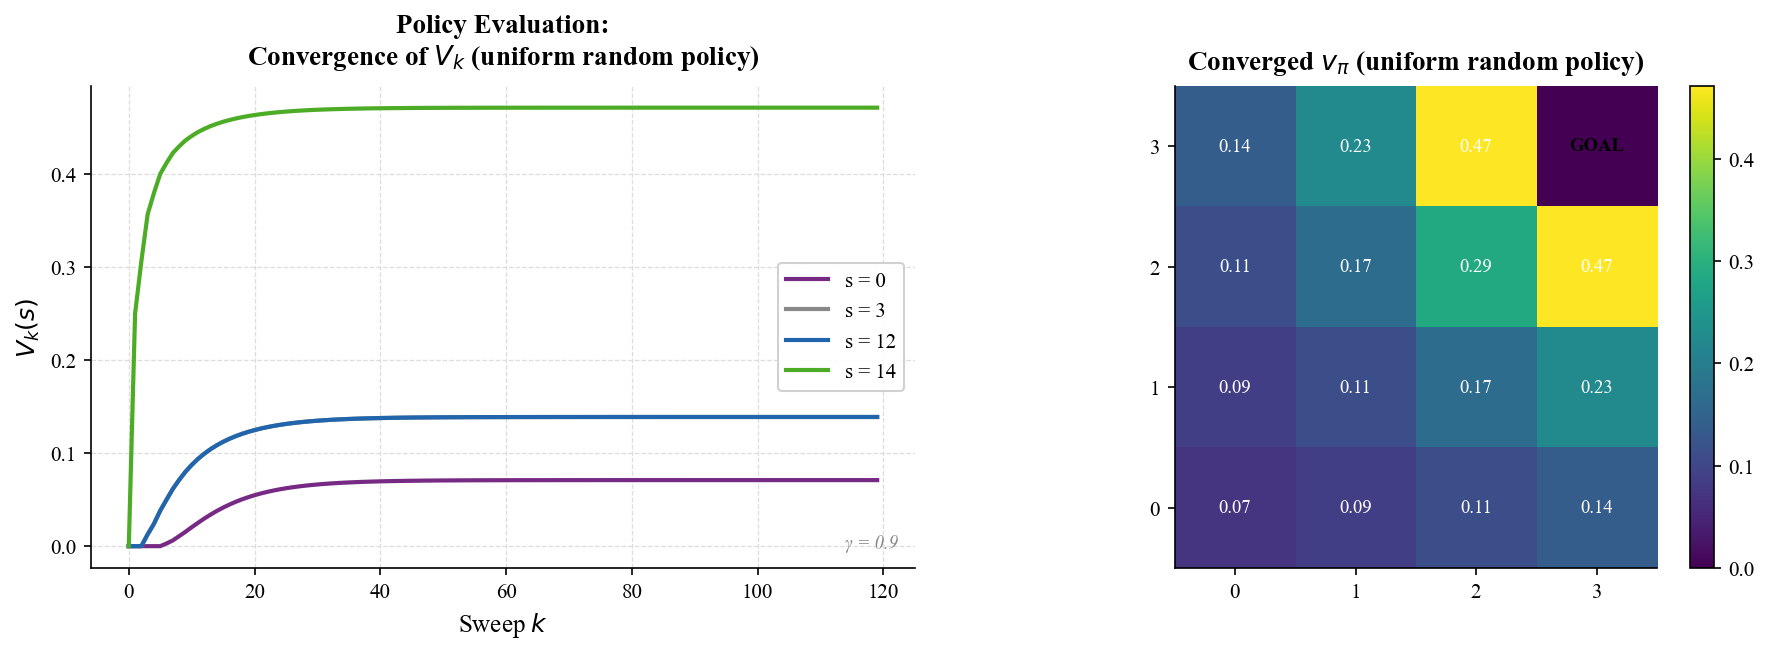

Saved fig1_policy_evaluation.pdf


In [3]:
uniform_policy = [np.ones(len(ACTIONS)) / len(ACTIONS) for _ in range(NS)]
V_pi, hist = policy_evaluation(uniform_policy)
print(f'policy evaluation converged in {len(hist) - 1} sweeps')
print(f'v_pi(goal-adjacent 14) = {V_pi[14]:.3f},  v_pi(corner 0) = {V_pi[0]:.3f}')

# ── Left: 若干状态的 V_k(s) 随扫描次数收敛 ─────────────────────
SELECT = [0, 3, 12, 14]          # 远角、远角、目标左侧、紧邻目标
LABELS  = [f's = {s}' for s in SELECT]
COLORS  = [C_PURPLE, C_GRAY, C_BLUE, C_GREEN]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ks = np.arange(len(hist))
for s, label, color in zip(SELECT, LABELS, COLORS):
    ax.plot(ks, [h[s] for h in hist], label=label, color=color)
ax.set_xlabel('Sweep $k$')
ax.set_ylabel('$V_k(s)$')
ax.set_title('Policy Evaluation:\nConvergence of $V_k$ (uniform random policy)')
ax.legend()
ax.text(0.98, 0.04, f'γ = {GAMMA}', transform=ax.transAxes,
        ha='right', fontsize=9, color=C_GRAY, style='italic')

# ── Right: 收敛后 v_π 的热力图 ─────────────────────────────────
ax2 = axes[1]
img = V_pi.reshape(N, N)
im = ax2.imshow(img, cmap='viridis', origin='lower')
ax2.set_xticks(range(N)); ax2.set_yticks(range(N))
ax2.set_xticklabels(range(N)); ax2.set_yticklabels(range(N))
ax2.set_title(r'Converged $v_\pi$ (uniform random policy)')
ax2.grid(False)
for r_ in range(N):
    for c_ in range(N):
        s = r_ * N + c_
        val = '' if s == GOAL else f'{V_pi[s]:.2f}'
        ax2.text(c_, r_, val, ha='center', va='center', fontsize=9,
                 color='white' if V_pi[s] < 0.5 else 'black')
        if s == GOAL:
            ax2.text(c_, r_, 'GOAL', ha='center', va='center', fontsize=9,
                     color='black', fontweight='bold')
ax2.set_title(r'Converged $v_\pi$ (uniform random policy)', pad=8)
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_policy_evaluation.pdf', bbox_inches='tight')
plt.show()

print('Saved fig1_policy_evaluation.pdf')

---
## Figure 2 — 值迭代：价值的“波”向外传播

值迭代 $V_{k+1}(s) = \max_a [R(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(s')]$ 每轮扫描把“最优一步 + 最优余下”组合起来。
从目标格（右下角）出发，高价值区域像水波一样逐轮向外扩展——紧邻目标一步可达的格价值最先变成 $1.0$，之后每多一轮，价值向外“辐射”一格。

value iteration converged in 7 sweeps
V*(14)= 1.0  V*(13)= 0.9  V*(0)= 0.59


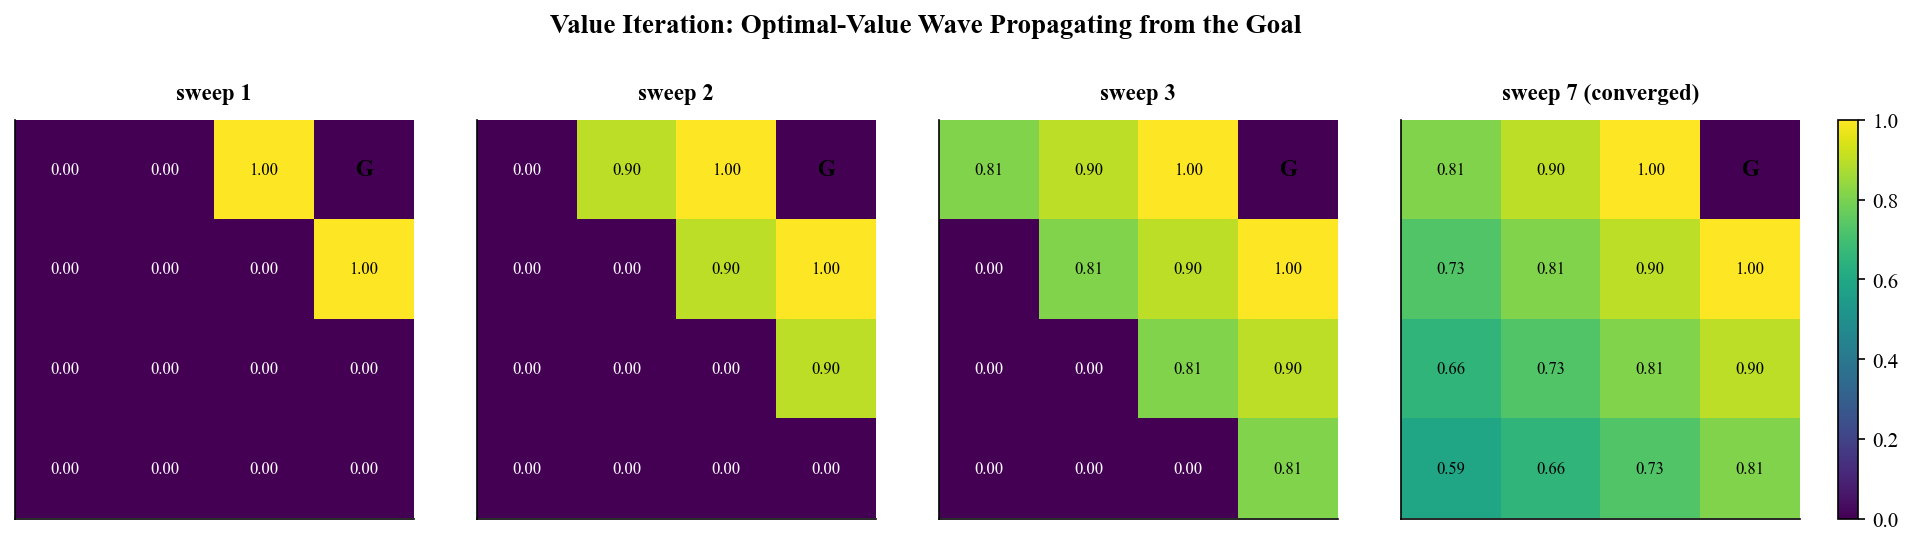

Saved fig2_value_iteration_wave.pdf


In [4]:
def value_iteration(tol=1e-8, max_sweeps=200):
    """返回 (收敛 V*, 每轮扫描历史, 每轮 Bellman 残差)。"""
    V = np.zeros(NS)
    history = [V.copy()]
    deltas = []
    for _ in range(max_sweeps):
        Vn = np.zeros(NS)
        for s in range(NS - 1):
            Vn[s] = max(r + GAMMA * V[ns] for a in ACTIONS for ns, r in [step(s, a)])
        d = np.max(np.abs(Vn - V))
        deltas.append(d)
        history.append(Vn.copy())
        V = Vn
        if d < tol:
            break
    return V, history, deltas


V_star, vi_hist, vi_deltas = value_iteration()
print(f'value iteration converged in {len(vi_deltas)} sweeps')
print('V*(14)=', round(V_star[14], 3), ' V*(13)=', round(V_star[13], 3),
      ' V*(0)=', round(V_star[0], 3))

# 选 4 个有代表性的扫描轮次
shown = [1, 2, 3, len(vi_hist) - 1]
titles = ['sweep 1', 'sweep 2', 'sweep 3', f'sweep {len(vi_hist)-1} (converged)']

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, k, title in zip(axes, shown, titles):
    img = vi_hist[k].reshape(N, N)
    im = ax.imshow(img, cmap='viridis', origin='lower', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)
    for r_ in range(N):
        for c_ in range(N):
            s = r_ * N + c_
            if s == GOAL:
                ax.text(c_, r_, 'G', ha='center', va='center', fontsize=11,
                        color='black', fontweight='bold')
            else:
                ax.text(c_, r_, f'{vi_hist[k][s]:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if vi_hist[k][s] < 0.5 else 'black')
fig.suptitle('Value Iteration: Optimal-Value Wave Propagating from the Goal',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
fig.savefig(f'{OUTDIR}/fig2_value_iteration_wave.pdf', bbox_inches='tight')
plt.show()

print('Saved fig2_value_iteration_wave.pdf')

---
## Figure 3 — 策略迭代 vs 值迭代

两种算法都收敛到同一个 $V^*$ 与最优策略（数值验证：$\max_s |V^{VI}(s)-V^{PI}(s)|=0$），但路径不同：

- **值迭代**：每一轮都对全状态做一次 Bellman 最优备份，残差 $\max_s |V_{k+1}-V_k|$ 单调几何衰减；
- **策略迭代**：交替“完整策略评估（可能很多轮扫描）→ 贪心改进”，残差呈阶梯式下降——每个阶段内部评估收敛，改进后策略变化又引入新残差。

扫描代价（本例）：值迭代 7 轮扫描即收敛；策略迭代 3 轮迭代、共 127 轮扫描（每轮评估都跑到收敛）。小网格上值迭代更省；策略迭代的优势在策略空间大、评估可截断时体现（广义策略迭代 / 异步 DP）。

policy iteration: 3 iterations, 127 total sweeps
max |V*_VI - V*_PI| = 0.00e+00


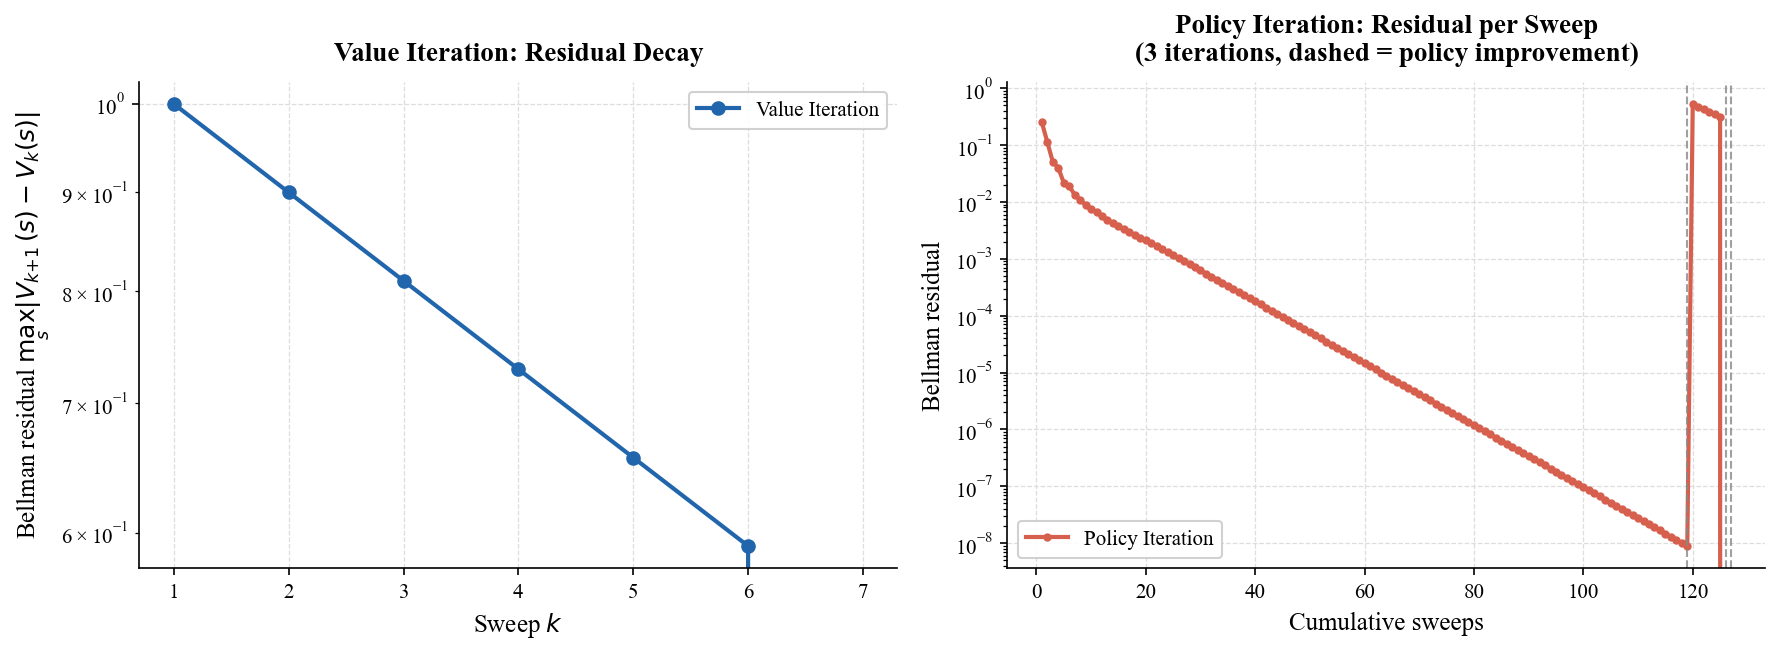

Saved fig3_policy_vs_value_iteration.pdf


In [5]:
def greedy_policy(V):
    """从 V 做一步贪心改进：每个状态选动作价值最高的动作（确定性策略）。"""
    pol = []
    for s in range(NS):
        vals = [r + GAMMA * V[ns] for a in ACTIONS for ns, r in [step(s, a)]]
        p = np.zeros(len(ACTIONS))
        p[int(np.argmax(vals))] = 1.0
        pol.append(p)
    return pol


def policy_iteration_trace(tol=1e-8):
    """带残差轨迹的策略迭代（评估采用“暖启动”：沿用上一轮的 V 继续扫描）。
    返回 (V, 每轮残差, 累计扫描数, 迭代次数, 每轮迭代结束时的累计扫描数)。"""
    policy = [np.ones(len(ACTIONS)) / len(ACTIONS) for _ in range(NS)]
    V = np.zeros(NS)
    residuals, cum, boundaries = [], [], []
    total, iters = 0, 0
    for _ in range(50):
        Vn = V.copy()
        while True:
            Vnn = np.zeros(NS)
            for s in range(NS - 1):
                Vnn[s] = sum(policy[s][a] * (r + GAMMA * Vn[ns])
                             for a in ACTIONS for ns, r in [step(s, a)])
            d = np.max(np.abs(Vnn - Vn))
            total += 1
            residuals.append(d); cum.append(total)
            Vn = Vnn
            if d < tol:
                break
        V = Vn
        boundaries.append(total)
        new_policy = greedy_policy(V)
        iters += 1
        changed = any(not np.allclose(p, q) for p, q in zip(policy, new_policy))
        policy = new_policy
        if not changed:
            break
    return V, residuals, cum, iters, boundaries


V_pi, pi_res, pi_cum, pi_iters, pi_bounds = policy_iteration_trace()
print(f'policy iteration: {pi_iters} iterations, {pi_cum[-1]} total sweeps')
print(f'max |V*_VI - V*_PI| = {np.max(np.abs(V_star - V_pi)):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Left: 值迭代残差 ──────────────────────────────────────────
ax = axes[0]
ax.semilogy(np.arange(1, len(vi_deltas) + 1), vi_deltas,
            marker='o', color=C_BLUE, label='Value Iteration')
ax.set_xlabel('Sweep $k$')
ax.set_ylabel('Bellman residual $\\max_s |V_{k+1}(s)-V_k(s)|$')
ax.set_title('Value Iteration: Residual Decay')
ax.legend()

# ── Right: 策略迭代残差 ───────────────────────────────────────
ax2 = axes[1]
ax2.semilogy(pi_cum, pi_res, marker='o', markersize=3, color=C_RED,
             label='Policy Iteration')
for b in pi_bounds:
    ax2.axvline(b, color=C_GRAY, linestyle='--', linewidth=1.0, alpha=0.8)
ax2.set_xlabel('Cumulative sweeps')
ax2.set_ylabel('Bellman residual')
ax2.set_title(f'Policy Iteration: Residual per Sweep\n'
              f'({pi_iters} iterations, dashed = policy improvement)')
ax2.legend()

fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_policy_vs_value_iteration.pdf', bbox_inches='tight')
plt.show()

print('Saved fig3_policy_vs_value_iteration.pdf')

## 小结

- **策略评估**把 Bellman 期望方程变成迭代：$V_{k+1} = R^\pi + \gamma P^\pi V_k$，收敛到 $v_\pi$；
- **值迭代**把 Bellman 最优方程变成迭代：每轮取 $\max_a$，残差单调衰减，价值波从目标格向外传播；
- **策略迭代**交替“评估 → 贪心改进”，迭代次数少但每轮评估代价高；
- 三者（及对应的动态规划思想）都**需要已知模型** $P(s',r|s,a)$——这正是下一章 TD 学习要抛弃的前提。

In [6]:
print('All figures saved:')
print('  fig1_policy_evaluation.pdf')
print('  fig2_value_iteration_wave.pdf')
print('  fig3_policy_vs_value_iteration.pdf')

All figures saved:
  fig1_policy_evaluation.pdf
  fig2_value_iteration_wave.pdf
  fig3_policy_vs_value_iteration.pdf
